In [1]:
# 1) Import the basic libraries.
import numpy as np
import pandas as pd
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    BaseCrossValidator, GridSearchCV, KFold, cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
!matplotlib inline

df = pd.read_csv("final_internship_data.csv")

print("Shape:", df.shape)
df.info()

'matplotlib' is not recognized as an internal or external command,
operable program or batch file.


Shape: (500000, 26)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  str    
 1   User Name          500000 non-null  str    
 2   Driver Name        500000 non-null  str    
 3   Car Condition      500000 non-null  str    
 4   Weather            500000 non-null  str    
 5   Traffic Condition  500000 non-null  str    
 6   key                500000 non-null  str    
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  str    
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64 

In [2]:
# count the gaps per column to see where the problem is
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
# the same count as a percentage, to compare with the 2-3% rule for dropping rows
miss_pct = (df.isnull().mean() * 100).round(4)
print("\nMissing % per column:\n", miss_pct[miss_pct > 0])
# count the ROWS with a gap, because many columns can be missing in the same few rows
has_missing = df.isnull().any(axis=1)
print("\nRows with any missing value:", has_missing.sum())
print("Share of rows with any missing: {:.4f}%".format(has_missing.mean() * 100))
# look at the incomplete rows to see what is missing (the fare or only the location)
print(df[has_missing][["dropoff_longitude", "dropoff_latitude", "distance", "fare_amount"]])
# compare incomplete rows with complete ones to see if they look like normal trips
num_cols = df.select_dtypes("number").columns.difference(
    ["dropoff_longitude", "dropoff_latitude", "distance"])
print("\nMean per group (False = complete, True = incomplete):")
print(df.groupby(has_missing)[num_cols].mean().T)
# save the row count and fare statistics to prove later that dropping changed nothing
rows_before = len(df)
fare_before = df["fare_amount"].describe()
# drop the rows with gaps: only 5 rows, and a filled coordinate would give a fake distance
df = df.dropna()
# confirm how many rows were removed and that the fare distribution did not change
print("\nRows removed:", rows_before - len(df))
print("Shape after dropping nulls:", df.shape)
print("\nfare_amount before vs after:")
print(pd.concat([fare_before, df["fare_amount"].describe()], axis=1, keys=["before", "after"]))

Missing values per column:
 dropoff_longitude    5
dropoff_latitude     5
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

Missing % per column:
 dropoff_longitude    0.001
dropoff_latitude     0.001
jfk_dist             0.001
ewr_dist             0.001
lga_dist             0.001
sol_dist             0.001
nyc_dist             0.001
distance             0.001
bearing              0.001
dtype: float64

Rows with any missing value: 5
Share of rows with any missing: 0.0010%
        dropoff_longitude  dropoff_latitude  distance  fare_amount
120227                NaN               NaN       NaN         12.5
245696                NaN               NaN       NaN         86.5
340533                NaN               NaN       NaN         27.5
428108                NaN               NaN       NaN         11.8
471472                NaN               NaN       NaN          

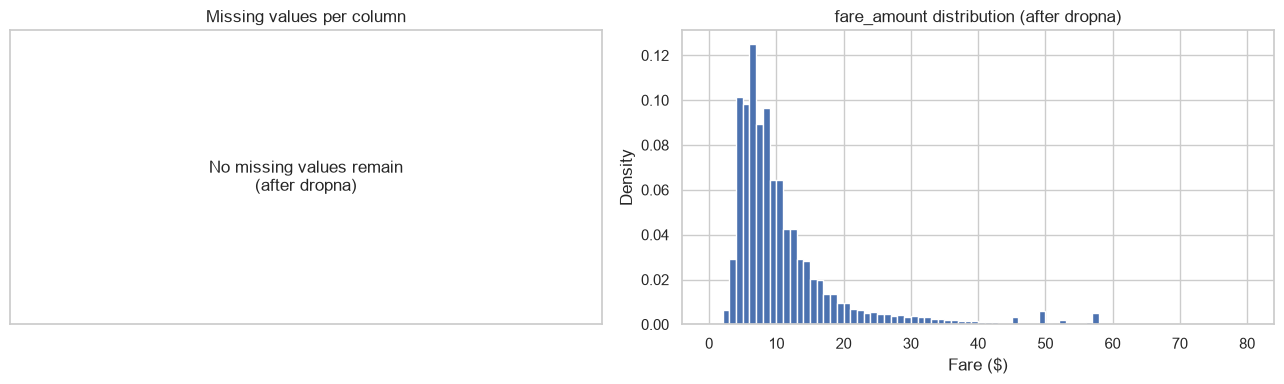

In [3]:
import matplotlib.pyplot as plt

# two panels: left shows what is still missing, right shows the fare shape after dropping
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
# draw the remaining gaps if there are any (log scale so small and big counts both show)
if not missing_counts.empty:
    missing_counts.plot(
        kind="bar",
        ax=axes[0]
    )
    axes[0].set_yscale("log")
    axes[0].set_title("Missing values per column (log scale)")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Number of missing values")
    axes[0].tick_params(axis="x", rotation=45)
# otherwise write a message, because an empty chart would confuse the reader
else:
    axes[0].text(
        0.5,
        0.5,
        "No missing values remain\n(after dropna)",
        ha="center",
        va="center",
        fontsize=12
    )
    axes[0].set_title("Missing values per column")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
# fare histogram to show that dropping 5 rows did not distort the target
axes[1].hist(
    df["fare_amount"],
    bins=80,
    range=(0, 80),
    density=True
)
axes[1].set_title("fare_amount distribution (after dropna)")
axes[1].set_xlabel("Fare ($)")
axes[1].set_ylabel("Density")
plt.tight_layout()
plt.show()

**Duplicates**
## Step 2: Detecting and Removing Duplicates
I checked exact, key-based, ID-ignoring and near-duplicate rows because a trip counted twice would overweight its route.

In [4]:
# count rows identical in every column, because a repeated trip would count double in training
n_dup = df.duplicated().sum()
print("Exact duplicate rows:", n_dup, "({:.4f}%)".format(n_dup / len(df) * 100))
# check repeated IDs, because the same ID twice can mean re-imported data
id_cols = [c for c in ["key", "Unnamed: 0"] if c in df.columns]
for c in id_cols:
    print(f"Repeated values in '{c}':", df[c].duplicated().sum())
# compare rows while ignoring the IDs, to catch the same trip stored under two IDs
cols_no_id = [c for c in df.columns if c not in id_cols]
print("Exact duplicates ignoring ID columns:", df.duplicated(subset=cols_no_id).sum())
# round the coordinates to about 11 meters to find near-duplicates, which we only count and never delete
coord_cols = ["pickup_longitude", "pickup_latitude",
              "dropoff_longitude", "dropoff_latitude"]
other_cols = [c for c in cols_no_id if c not in coord_cols and c != "fare_amount"]
rounded = df[cols_no_id].copy()
rounded[coord_cols] = rounded[coord_cols].round(4)
near_mask = rounded.duplicated(subset=coord_cols + other_cols, keep=False) \
    & ~df.duplicated(subset=cols_no_id, keep=False)
print("Near-duplicate rows (not exact):", near_mask.sum())
# drop only exact duplicates, because two real trips can look almost the same
rows_before = len(df)
df = df.drop_duplicates(keep="first")
print("Rows removed:", rows_before - len(df))
print("Shape after dropping duplicates:", df.shape)

Exact duplicate rows: 0 (0.0000%)
Repeated values in 'key': 0
Exact duplicates ignoring ID columns: 0
Near-duplicate rows (not exact): 0
Rows removed: 0
Shape after dropping duplicates: (499995, 26)


**Encoding**
## Step 3: Encoding Categorical Variables
I used fixed ordinal maps for Traffic and Car condition because they have a real order, and one-hot encoding for Weather because it has no order and only a few categories.

In [5]:
# drop the identifier columns, because they are unique per row so the model could only memorize them
drop_cols = ["User ID", "key", "User Name", "Driver Name",
             "pickup_datetime", "Unnamed: 0"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Shape after dropping identifiers:", df.shape)
# set the order by hand, because automatic encoders number the labels alphabetically and break the real order
traffic_map = {"Flow Traffic": 0, "Dense Traffic": 1, "Congested Traffic": 2}
car_map = {"Bad": 0, "Good": 1, "Very Good": 2, "Excellent": 3}
# .map() turns any label not in the dictionary into NaN, so a typo shows up immediately
df["Traffic Condition"] = df["Traffic Condition"].map(traffic_map)
df["Car Condition"] = df["Car Condition"].map(car_map)
# check that no label was missed
print("\nNaN after ordinal mapping:\n",
      df[["Traffic Condition", "Car Condition"]].isnull().sum())
# one-hot encode Weather because it has no order, and drop_first avoids the dummy trap
df = pd.get_dummies(df, columns=["Weather"], drop_first=True, dtype=int)
# confirm that every column is numeric now, because models cannot use text
print("\nRemaining non-numeric columns:",
      df.select_dtypes(exclude="number").columns.tolist())
print("Final shape:", df.shape)
# check if the encoded columns carry any signal about the fare
enc_cols = ["Traffic Condition", "Car Condition"] \
    + [c for c in df.columns if c.startswith("Weather_")]
print("\nCorrelation with fare_amount:")
print(df[enc_cols + ["fare_amount"]].corr()["fare_amount"].drop("fare_amount").round(4))
# check duplicates again, because encoding can make two different rows identical
n_dup_after = df.duplicated().sum()
print("\nDuplicate rows after encoding:", n_dup_after)
rows_before = len(df)
df = df.drop_duplicates(keep="first")
print("Rows removed:", rows_before - len(df), "| Shape:", df.shape)

Shape after dropping identifiers: (499995, 21)

NaN after ordinal mapping:
 Traffic Condition    0
Car Condition        0
dtype: int64

Remaining non-numeric columns: []
Final shape: (499995, 24)

Correlation with fare_amount:
Traffic Condition    0.0031
Car Condition        0.0019
Weather_rainy       -0.0000
Weather_stormy      -0.0006
Weather_sunny        0.0000
Weather_windy       -0.0005
Name: fare_amount, dtype: float64

Duplicate rows after encoding: 0
Rows removed: 0 | Shape: (499995, 24)


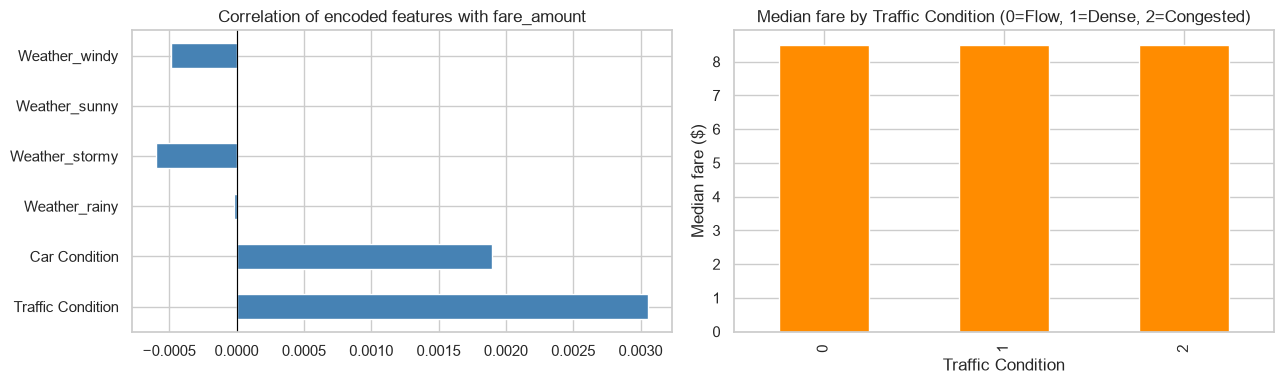

In [6]:
# two panels to see if the encoded columns matter for the fare
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# bars near zero mean the encoded column has no link with the fare
df[enc_cols + ["fare_amount"]].corr()["fare_amount"].drop("fare_amount") \
    .plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Correlation of encoded features with fare_amount")
# equal bars mean heavier traffic does not make the fare higher
df.groupby("Traffic Condition")["fare_amount"].median() \
    .plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Median fare by Traffic Condition (0=Flow, 1=Dense, 2=Congested)")
axes[1].set_ylabel("Median fare ($)")
plt.tight_layout(); plt.show()


**Scaling**
## Step 4: Feature Scaling
I used RobustScaler on the continuous features because fares and distances have extreme values that would distort the mean and standard deviation, and it is fitted inside the Pipeline so test data never influences it.

In [8]:
# list the columns we must not scale, because 0/1 flags and ordered codes already have a clear meaning
skip_cols = ["Car Condition", "Traffic Condition", "after_2012", "is_weekend",
             "is_jfk_manhattan"] \
    + [c for c in df.columns if c.startswith("Weather_")]
# scale everything else, plus the new continuous features the Pipeline will create later
scale_cols = [c for c in df.columns if c not in skip_cols and c != "fare_amount"] \
    + ["log_distance", "dist_after_2012", "hour_sin", "hour_cos",
       "hour_sin_weekend", "hour_cos_weekend", "dist_jfk_manhattan"]
print("Columns to scale:", scale_cols)
# only define the scaler here, because the Pipeline fits it on training rows only (no test data leaks in)
scaler_step = ("scale", RobustScaler(), scale_cols)

Columns to scale: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day', 'month', 'weekday', 'year', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance', 'bearing', 'log_distance', 'dist_after_2012', 'hour_sin', 'hour_cos', 'hour_sin_weekend', 'hour_cos_weekend', 'dist_jfk_manhattan']


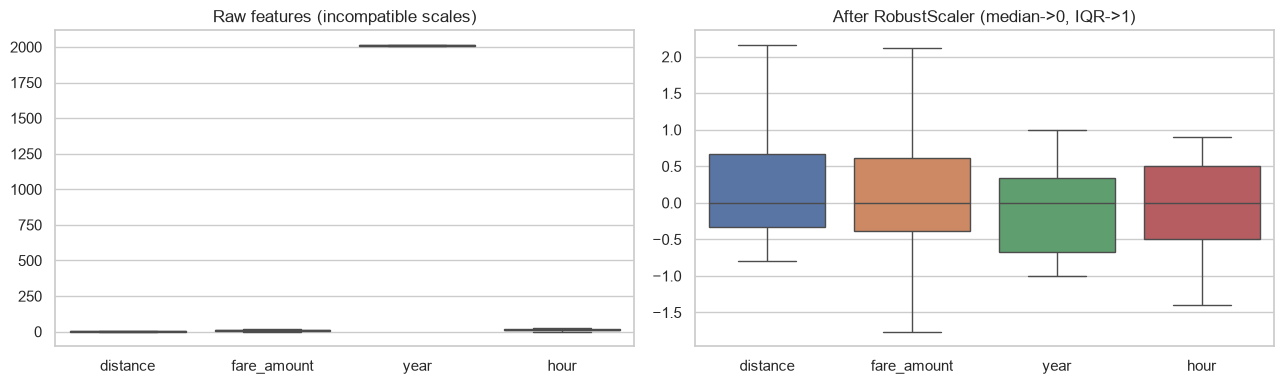

In [9]:
# pick four columns with very different scales to show what scaling does
demo_cols = ["distance", "fare_amount", "year", "hour"]
# scale them just for the chart, because the real scaler is fitted inside the Pipeline
scaled_demo = pd.DataFrame(
    RobustScaler().fit(df[demo_cols]).transform(df[demo_cols]),
    columns=demo_cols)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# before scaling the year dwarfs the other columns
sns.boxplot(data=df[demo_cols], ax=axes[0], showfliers=False)
axes[0].set_title("Raw features (incompatible scales)")
# after scaling the columns are comparable
sns.boxplot(data=scaled_demo, ax=axes[1], showfliers=False)
axes[1].set_title("After RobustScaler (median->0, IQR->1)")
plt.tight_layout(); plt.show()

**Feature Extraction**
## Step 5: Feature Extraction
I added log1p(distance) because a fare is a starting fee plus a price per km that falls on longer trips, a curve that a straight line on raw distance cannot follow.

In [10]:
# a class so the Pipeline can rebuild this feature in every fold
class AddLogDistance(BaseEstimator, TransformerMixin):
    # nothing to learn from the data, so fit just returns itself
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # work on a copy so the original data is never changed
        X_out = X.copy()
        # log1p because the fare curve bends with distance, and log1p(0) = 0 while log(0) would break
        X_out["log_distance"] = np.log1p(X_out["distance"].clip(lower=0))
        return X_out

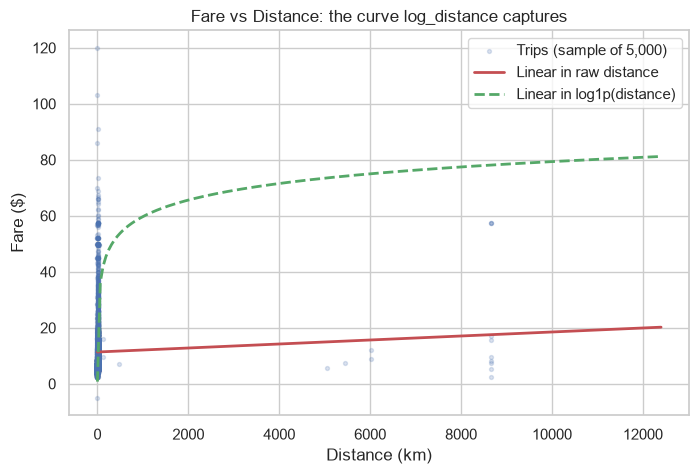

In [11]:
# take 5,000 random trips, because 500,000 dots would melt into one blob
sample = df.sample(min(5000, len(df)), random_state=42)
# fit one straight line on raw distance and one on log distance to compare them
a_lin, b_lin = np.polyfit(df["distance"], df["fare_amount"], 1)
a_log, b_log = np.polyfit(np.log1p(df["distance"]), df["fare_amount"], 1)
plt.figure(figsize=(8, 5))
# the dots show the real fare vs distance
plt.scatter(sample["distance"], sample["fare_amount"], s=8, alpha=0.2,
            label="Trips (sample of 5,000)")
x_line = np.linspace(0, df["distance"].max(), 200)
# red = straight line on raw distance, green = line on log distance (it bends like the data)
plt.plot(x_line, a_lin * x_line + b_lin, "r-", lw=2, label="Linear in raw distance")
plt.plot(x_line, a_log * np.log1p(x_line) + b_log, "g--", lw=2,
         label="Linear in log1p(distance)")
plt.xlabel("Distance (km)"); plt.ylabel("Fare ($)")
plt.title("Fare vs Distance: the curve log_distance captures")
plt.legend(); plt.show()

**Feature Engineering**
## Step 6: Feature Engineering
I added features for the September 2012 price jump, the hour of the day (sin/cos with a weekend interaction) and the fixed JFK-Manhattan fares, because the EDA showed each of these patterns in the fares.

In [12]:
# distance between two points on the Earth in km (coordinates are already in radians)
def haversine_km(lat1, lon1, lat2, lon2):
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * 6371 * np.arcsin(np.sqrt(a))
# fixed landmarks (known facts, not learned from data, so nothing leaks)
JFK = (np.radians(40.6413), np.radians(-73.7781))
MIDTOWN = (np.radians(40.7580), np.radians(-73.9855))
# one Pipeline step that adds the features found in the EDA
class AddEdaFeatures(BaseEstimator, TransformerMixin):
    """Adds the EDA-driven features listed in the markdown cell above."""
    # nothing to learn, only fixed constants are used
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_out = X.copy()
        # flag trips from September 2012 on, because the price jumped once at that date
        X_out["after_2012"] = (
            (X_out["year"] > 2012)
            | ((X_out["year"] == 2012) & (X_out["month"] >= 9))
        ).astype(int)
        # multiply by distance, because the jump was in the price per km
        X_out["dist_after_2012"] = X_out["distance"] * X_out["after_2012"]
        # turn the hour into a circle, because hour 23 is next to hour 0 (both sin and cos are needed)
        X_out["hour_sin"] = np.sin(2 * np.pi * X_out["hour"] / 24)
        X_out["hour_cos"] = np.cos(2 * np.pi * X_out["hour"] / 24)
        # weekend flag (weekday 5 and 6)
        X_out["is_weekend"] = (X_out["weekday"] >= 5).astype(int)
        # the same hour can behave differently on weekends
        X_out["hour_sin_weekend"] = X_out["hour_sin"] * X_out["is_weekend"]
        X_out["hour_cos_weekend"] = X_out["hour_cos"] * X_out["is_weekend"]
        # JFK to Manhattan trips pay a fixed fare, so flag them
        pickup_jfk = haversine_km(X_out["pickup_latitude"], X_out["pickup_longitude"], *JFK) < 2
        drop_jfk = haversine_km(X_out["dropoff_latitude"], X_out["dropoff_longitude"], *JFK) < 2
        pickup_mid = haversine_km(X_out["pickup_latitude"], X_out["pickup_longitude"], *MIDTOWN) < 5
        drop_mid = haversine_km(X_out["dropoff_latitude"], X_out["dropoff_longitude"], *MIDTOWN) < 5
        X_out["is_jfk_manhattan"] = ((pickup_jfk & drop_mid) | (drop_jfk & pickup_mid)).astype(int)
        # distance matters less for fixed fares, so give them their own price per km
        X_out["dist_jfk_manhattan"] = X_out["distance"] * X_out["is_jfk_manhattan"]
        return X_out

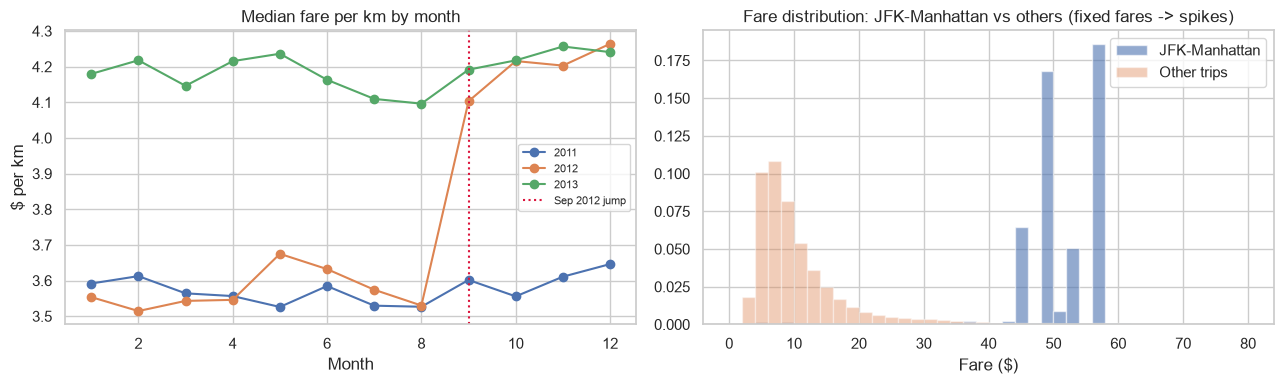

In [13]:
# fare per km removes the effect of trip length, so price changes become visible
fpkm = df["fare_amount"] / df["distance"]
# keep only the years around the price jump
mask_11_13 = (df["year"] >= 2011) & (df["year"] <= 2013)
# median per year and month, because the median ignores extreme fares
monthly = fpkm[mask_11_13].groupby(
    [df.loc[mask_11_13, "year"], df.loc[mask_11_13, "month"]]).median().unstack()
plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
# one line per year, so a step in 2012 shows that the price changed at one moment
for yr in monthly.index:
    plt.plot(monthly.columns, monthly.loc[yr], marker="o", label=yr)
plt.axvline(9, color="crimson", linestyle=":", label="Sep 2012 jump")
plt.title("Median fare per km by month"); plt.xlabel("Month"); plt.ylabel("$ per km")
plt.legend(fontsize=8)
# flag the JFK-Manhattan trips with the same rule as the Pipeline step
X_tmp = df.copy()
pj = haversine_km(X_tmp["pickup_latitude"], X_tmp["pickup_longitude"], *JFK) < 2
dj = haversine_km(X_tmp["dropoff_latitude"], X_tmp["dropoff_longitude"], *JFK) < 2
pm = haversine_km(X_tmp["pickup_latitude"], X_tmp["pickup_longitude"], *MIDTOWN) < 5
dm = haversine_km(X_tmp["dropoff_latitude"], X_tmp["dropoff_longitude"], *MIDTOWN) < 5
flag = (pj & dm) | (dj & pm)
plt.subplot(1, 2, 2)
# spikes at a few exact values are the fixed fares
plt.hist(df.loc[flag, "fare_amount"], bins=40, range=(0, 80), density=True,
         alpha=0.6, label="JFK-Manhattan")
plt.hist(df.loc[~flag, "fare_amount"], bins=40, range=(0, 80), density=True,
         alpha=0.4, label="Other trips")
plt.title("Fare distribution: JFK-Manhattan vs others (fixed fares -> spikes)")
plt.xlabel("Fare ($)"); plt.legend()
plt.tight_layout(); plt.show()

**Feature Selection**
## Step 7: Feature Selection
I used SelectKBest with mutual information (k = 14) because it keeps the features that carry signal about the fare and drops the near-random ones, and it runs inside the Pipeline so each fold selects using only its own training rows.

In [14]:
# score each feature against log1p(fare), the target the model really trains on
def mutual_info_log_fare(X, y):
    y = np.asarray(y, dtype=float)
    # use at most 50,000 rows, because exact mutual information on all rows is slow
    n_sample = min(50000, len(X))
    # fixed seed so the ranking is the same every run
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X), size=n_sample, replace=False)
    # mutual information also sees non-linear links that correlation misses
    return mutual_info_regression(X[idx], np.log1p(y[idx]), random_state=42)
# keep the 14 best features, selected inside the Pipeline so the test data is never used
select_step = ("select", SelectKBest(score_func=mutual_info_log_fare, k=14))

**Outliers**
## Step 8: Outlier Detection & Treatment
I removed only impossible values (coordinates outside New York, invalid passenger counts, non-positive fares) and kept unusual but real fares such as long trips and airport rides, because the first are recording errors and the second are patterns the model must learn.

In [15]:
coord_cols = ["pickup_longitude", "pickup_latitude",
              "dropoff_longitude", "dropoff_latitude"]
# look at the min and max first, to see which values are impossible
print(df[coord_cols + ["passenger_count", "fare_amount", "distance"]]
      .agg(["min", "max"]).T)
# the New York box in radians, because this dataset stores coordinates in radians
lat_lo, lat_hi = np.deg2rad(40.5), np.deg2rad(41.0)
lon_lo, lon_hi = np.deg2rad(-74.3), np.deg2rad(-73.7)
# one mask of valid rows, so counting and removing always use the same rule
valid = (
    df["pickup_latitude"].between(lat_lo, lat_hi)
    & df["dropoff_latitude"].between(lat_lo, lat_hi)
    & df["pickup_longitude"].between(lon_lo, lon_hi)
    & df["dropoff_longitude"].between(lon_lo, lon_hi)
    & df["passenger_count"].between(1, 6)
    & (df["fare_amount"] > 0)
)
# count the invalid rows before deleting anything
print("\nInvalid rows:", (~valid).sum(), "({:.3f}%)".format((~valid).mean() * 100))
# remove them: these are recording errors, not rare trips
rows_before = len(df)
df = df[valid].copy()
print("Rows removed:", rows_before - len(df))
print("Shape after removing invalid values:", df.shape)
# a second rule for fares that cannot be true for the distance (used later on training rows only)
def fare_error_mask(fare, distance):
    fare = np.asarray(fare, dtype=float)
    distance = np.asarray(distance, dtype=float)
    # fare per km, computed only when the trip is longer than 0.1 km
    fare_per_dist = np.divide(
        fare, distance,
        out=np.full_like(fare, np.inf, dtype=float),
        where=distance > 0.1,
    )
    # impossible fares: below the $2.50 minimum, a huge fare for a tiny trip, or over $100 per km
    return (
        (fare < 2.5)
        | ((distance < 0.1) & (fare > 100))
        | ((distance > 0.1) & (fare_per_dist > 100))
    )

                         min           max
pickup_longitude  -52.119764     37.360538
pickup_latitude   -54.389440     29.724576
dropoff_longitude -59.049665      0.712985
dropoff_latitude  -44.676047      7.061893
passenger_count     0.000000      6.000000
fare_amount       -44.900000    500.000000
distance            0.000000  12399.956433

Invalid rows: 12783 (2.557%)
Rows removed: 12783
Shape after removing invalid values: (487212, 24)


C:\Users\esraa\AppData\Local\Temp\ipykernel_9304\675975911.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()
C:\Users\esraa\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


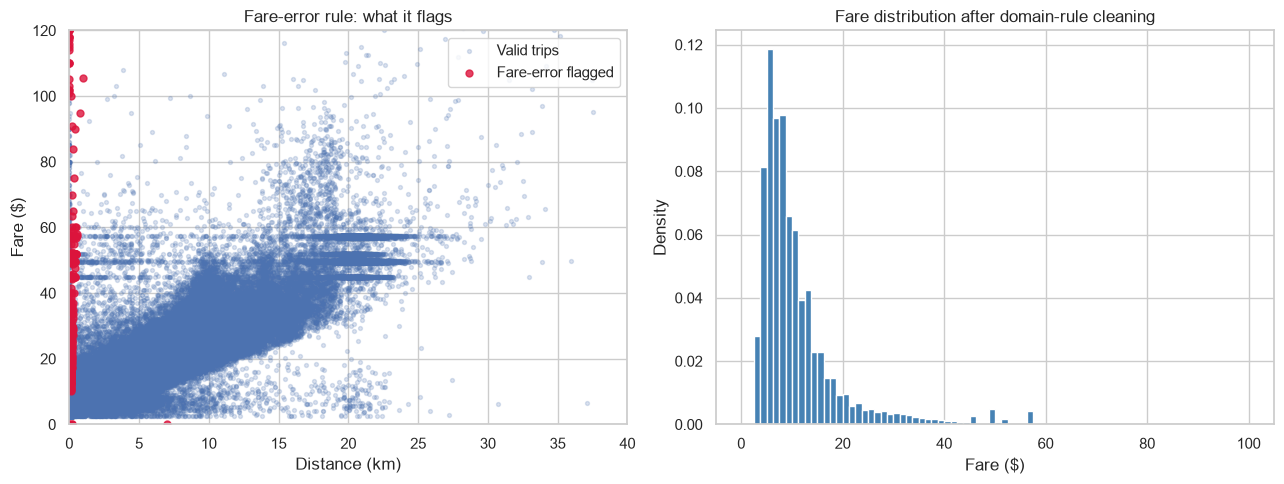

In [16]:
# flag the impossible fares to see what the rule targets
flagged = fare_error_mask(df["fare_amount"], df["distance"])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# normal trips
axes[0].scatter(df.loc[~flagged, "distance"], df.loc[~flagged, "fare_amount"],
                s=8, alpha=0.2, label="Valid trips")
# flagged trips in red, like $300 for 1 km
axes[0].scatter(df.loc[flagged, "distance"], df.loc[flagged, "fare_amount"],
                s=25, alpha=0.8, color="crimson", label="Fare-error flagged")
axes[0].set_xlim(0, 40); axes[0].set_ylim(0, 120)
axes[0].set_xlabel("Distance (km)"); axes[0].set_ylabel("Fare ($)")
axes[0].set_title("Fare-error rule: what it flags"); axes[0].legend()
# the fare distribution after cleaning, to see that only the impossible tail was cut
axes[1].hist(df["fare_amount"], bins=80, range=(0, 100), density=True,
             color="steelblue")
axes[1].set_title("Fare distribution after domain-rule cleaning")
axes[1].set_xlabel("Fare ($)"); axes[1].set_ylabel("Density")
plt.tight_layout(); plt.show()

**Train/Test Split**
## Step 9: Train/Test Split and Avoiding Data Leakage
I split the data 80/20 at random (random_state=42) before fitting anything, because trips are independent rows rather than a time series, and splitting first keeps every scaler and selector away from the test data.

In [17]:
# separate the features from the answer we want to predict
X = df.drop(columns=["fare_amount"])
y = df["fare_amount"]
# split before fitting anything, so the test set stays unseen (random because trips are independent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# check the sizes of the two parts
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (389769, 23) | Test: (97443, 23)


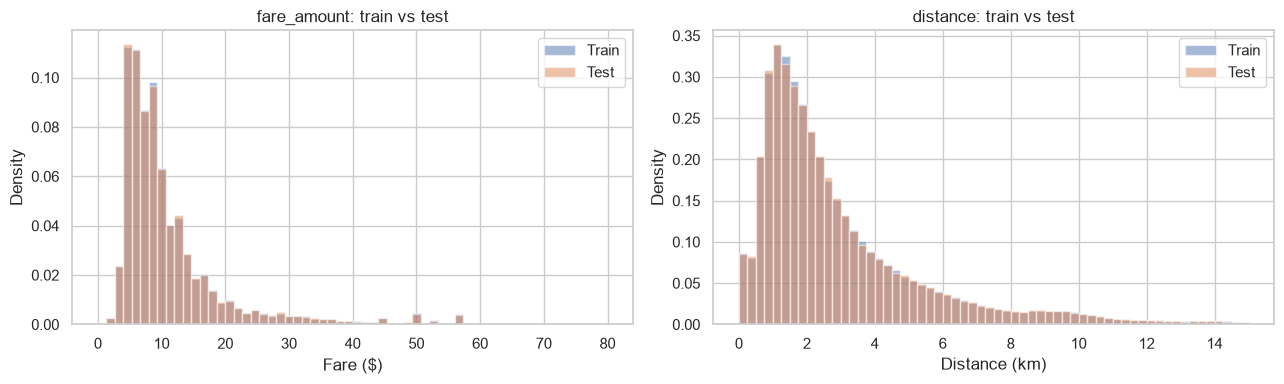

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# overlapping bars show that train and test have the same fare shape
axes[0].hist(y_train, bins=60, range=(0, 80), density=True, alpha=0.5, label="Train")
axes[0].hist(y_test, bins=60, range=(0, 80), density=True, alpha=0.5, label="Test")
axes[0].set_title("fare_amount: train vs test"); axes[0].legend()
axes[0].set_xlabel("Fare ($)"); axes[0].set_ylabel("Density")
# the same check for the strongest feature
axes[1].hist(X_train["distance"], bins=60, range=(0, 15), density=True,
             alpha=0.5, label="Train")
axes[1].hist(X_test["distance"], bins=60, range=(0, 15), density=True,
             alpha=0.5, label="Test")
axes[1].set_title("distance: train vs test"); axes[1].legend()
axes[1].set_xlabel("Distance (km)"); axes[1].set_ylabel("Density")
plt.tight_layout(); plt.show()

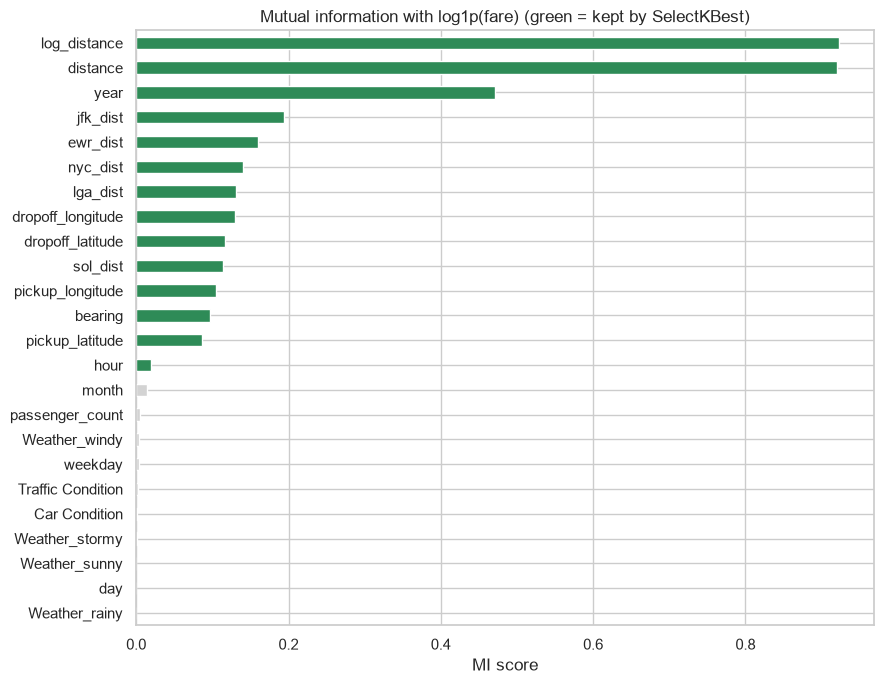

Features kept by k=14: ['log_distance', 'distance', 'year', 'jfk_dist', 'ewr_dist', 'nyc_dist', 'lga_dist', 'dropoff_longitude', 'dropoff_latitude', 'sol_dist', 'pickup_longitude', 'bearing', 'pickup_latitude', 'hour']


In [19]:
# display only: which features mutual information ranks highest (the real selection runs inside the Pipeline)
X_display = X_train.copy()
X_display["log_distance"] = np.log1p(X_display["distance"].clip(lower=0))
mi_scores = pd.Series(
    mutual_info_regression(X_display, np.log1p(y_train), random_state=42),
    index=X_display.columns,
).sort_values(ascending=False)
plt.figure(figsize=(9, 7))
# green = the 14 features that SelectKBest keeps
colors = ["seagreen" if i < 14 else "lightgray" for i in range(len(mi_scores))]
mi_scores.plot(kind="barh", color=colors)
plt.gca().invert_yaxis()
plt.title("Mutual information with log1p(fare) (green = kept by SelectKBest)")
plt.xlabel("MI score")
plt.tight_layout(); plt.show()
print("Features kept by k=14:", mi_scores.index[:14].tolist())

**Cross-Validation**
## Step 10: Cross-Validation
I used 5-fold cross-validation over the whole Pipeline (the target is trained as log1p(fare) and converted back to dollars) because a single split can be lucky and this refits every step on training rows only.

In [20]:
# our own splitter: it removes impossible fares from the TRAINING part of each fold only
class OutlierAwareKFold(BaseCrossValidator):
    # store the settings (sklearn needs them stored as they are)
    def __init__(self, n_splits=5, shuffle=True, random_state=42):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
    # sklearn asks how many folds there are
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits
    def split(self, X, y, groups=None):
        # normal shuffled 5-fold, because trips are independent rows
        splitter = KFold(n_splits=self.n_splits, shuffle=self.shuffle,
                         random_state=self.random_state)
        y_array = np.asarray(y, dtype=float)
        # distance comes from the raw table, so it exists before the Pipeline runs
        distance = X["distance"].to_numpy(dtype=float)
        for train_idx, valid_idx in splitter.split(X, y_array, groups):
            # flag impossible fares using this fold's training rows only
            bad_train = fare_error_mask(y_array[train_idx], distance[train_idx])
            # keep the validation rows untouched so the score stays realistic
            yield train_idx[~bad_train], valid_idx
# one splitter reused everywhere, so every comparison uses the same folds
cv_strategy = OutlierAwareKFold(n_splits=5, shuffle=True, random_state=42)
# a model wrapper that trains on log1p(fare) and returns dollars
class LogTargetRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_kind="ridge", alpha=1.0):
        self.model_kind = model_kind
        self.alpha = alpha
    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        # remember the fare range so predictions can be clipped later
        self.y_min_ = float(np.min(y))
        self.y_max_ = float(np.max(y))
        # linear for the baseline, Ridge for the tuned model
        if self.model_kind == "linear":
            self.regressor_ = LinearRegression()
        else:
            self.regressor_ = Ridge(alpha=self.alpha)
        # log1p flattens the fare curve so a linear model fits it better
        self.regressor_.fit(X, np.log1p(y))
        return self
    def predict(self, X):
        # expm1 undoes log1p, so errors are reported in dollars
        pred = np.expm1(self.regressor_.predict(X))
        # clip so a wild prediction cannot become $1M or a negative fare
        return np.clip(pred, self.y_min_, self.y_max_)
# the full Pipeline: every fold refits all steps, in this order: features, scaling, selection, model
model_pipeline = Pipeline(
    steps=[
        ("log_distance", AddLogDistance()),
        ("eda_features", AddEdaFeatures()),
        ("preprocess",
         ColumnTransformer(transformers=[scaler_step], remainder="passthrough")),
        ("select", select_step[1]),
        ("model", LogTargetRegressor()),
    ]
)
# the three metrics, because each one answers a different question
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}
# baseline: the same Pipeline with plain Linear Regression, so only the model is different
baseline_pipeline = clone(model_pipeline).set_params(model__model_kind="linear")
# cross-validate on the training data only, because the test set is kept for the end
baseline_cv = cross_validate(
    baseline_pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring)
# sklearn returns errors as negatives, so flip the sign back to dollars
baseline_cv_report = pd.DataFrame({
    "MAE ($)": -baseline_cv["test_mae"],
    "RMSE ($)": -baseline_cv["test_rmse"],
    "R2": baseline_cv["test_r2"],
})
# the mean is the estimate and the std shows how stable it is
print("Baseline CV per fold:")
print(baseline_cv_report.round(4))
print("\nBaseline CV mean:\n", baseline_cv_report.mean().round(4))
print("\nBaseline CV std:\n", baseline_cv_report.std().round(4))

Baseline CV per fold:
   MAE ($)  RMSE ($)      R2
0   2.1364    4.4535  0.7766
1   2.1714    4.7465  0.7608
2   2.1532    4.8833  0.7469
3   2.1387    4.4673  0.7704
4   2.1572    5.3143  0.7101

Baseline CV mean:
 MAE ($)     2.1514
RMSE ($)    4.7730
R2          0.7530
dtype: float64

Baseline CV std:
 MAE ($)     0.0143
RMSE ($)    0.3541
R2          0.0265
dtype: float64


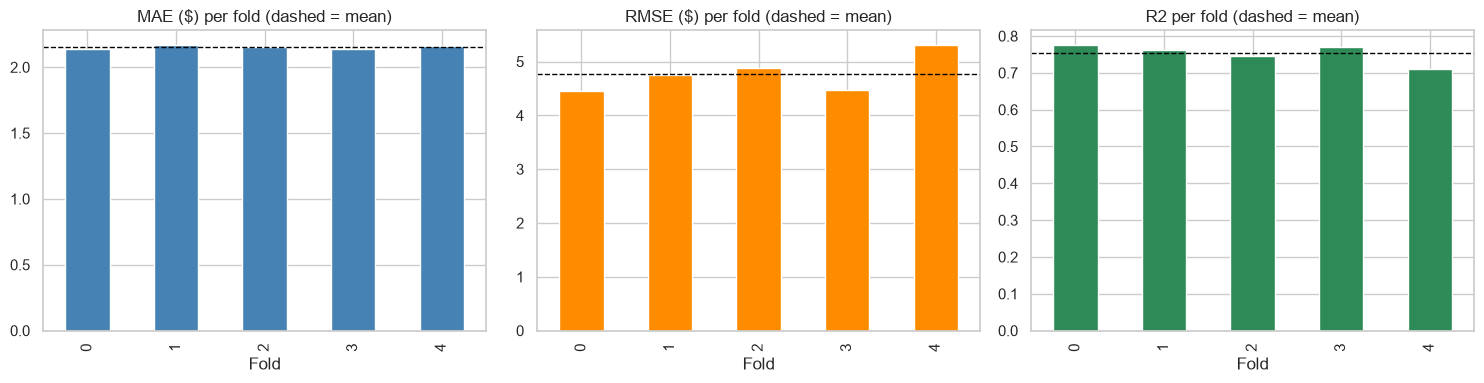

In [21]:
# one panel per metric
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, baseline_cv_report.columns,
                          ["steelblue", "darkorange", "seagreen"]):
    # one bar per fold
    baseline_cv_report[col].plot(kind="bar", ax=ax, color=color)
    # the dashed line is the mean, bars close to it mean a stable model
    ax.axhline(baseline_cv_report[col].mean(), color="black", ls="--", lw=1)
    ax.set_title(f"{col} per fold (dashed = mean)"); ax.set_xlabel("Fold")
plt.tight_layout(); plt.show()

**Tuning (Ridge)**
## Step 11: Hyperparameter Tuning (Ridge)
I tuned Ridge's alpha with GridSearchCV over six log-spaced values on the same 5 folds, because the search space is tiny and identical folds make baseline vs tuned a fair comparison.

In [23]:
# alpha values spread on a log scale, because Ridge's effect is multiplicative
param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
# a grid search is enough for 6 values, on the same folds as the baseline
grid = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=scoring,
    refit="rmse",
)
# search on the training data only, so the test set stays locked
grid.fit(X_train, y_train)
# one row per alpha (sign flipped back to dollars)
out = pd.DataFrame({
    "alpha": param_grid["model__alpha"],
    "RMSE ($)": -grid.cv_results_["mean_test_rmse"],
    "MAE ($)": -grid.cv_results_["mean_test_mae"],
    "R2": grid.cv_results_["mean_test_r2"],
})
print(out.round(4).to_string(index=False))
print("\nBest params:", grid.best_params_)
# the scores are negative, so the best CV RMSE is the highest stored value
print("Best CV RMSE ($):", round(-grid.cv_results_["mean_test_rmse"].max(), 4))

  alpha  RMSE ($)  MAE ($)     R2
  0.001    4.7730   2.1514 0.7530
  0.010    4.7730   2.1514 0.7530
  0.100    4.7730   2.1514 0.7530
  1.000    4.7730   2.1514 0.7530
 10.000    4.7731   2.1515 0.7530
100.000    4.7754   2.1531 0.7527

Best params: {'model__alpha': 0.001}
Best CV RMSE ($): 4.773


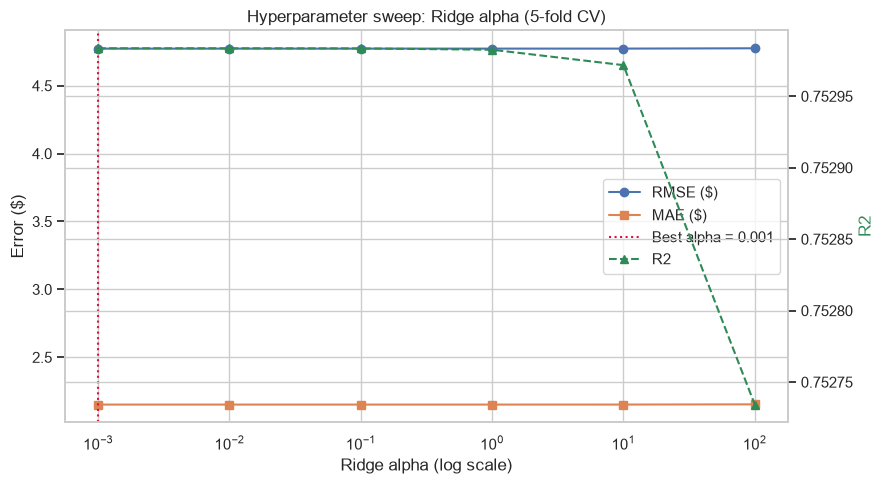

In [24]:
fig, ax1 = plt.subplots(figsize=(9, 5))
# RMSE and MAE share the left axis because both are in dollars
ax1.plot(out["alpha"], out["RMSE ($)"], "o-", label="RMSE ($)")
ax1.plot(out["alpha"], out["MAE ($)"], "s-", label="MAE ($)")
ax1.set_xscale("log"); ax1.set_xlabel("Ridge alpha (log scale)")
ax1.set_ylabel("Error ($)")
# R2 has its own axis because it is a ratio, not dollars
ax2 = ax1.twinx()
ax2.plot(out["alpha"], out["R2"], "^--", color="seagreen", label="R2")
ax2.set_ylabel("R2", color="seagreen")
# mark the best alpha
best = out.loc[out["RMSE ($)"].idxmin()]
ax1.axvline(best["alpha"], color="crimson", ls=":",
            label=f"Best alpha = {best['alpha']}")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="best")
ax1.set_title("Hyperparameter sweep: Ridge alpha (5-fold CV)")
plt.tight_layout(); plt.show()

**Baseline vs Tuned**
## Step 12: Baseline vs Tuned Ridge on the Test Set
I fitted the baseline (Linear Regression) and the tuned Ridge on the same cleaned training rows and scored both on the untouched test set, so any difference comes from the model alone.

In [25]:
# apply the fare-error rule to the training rows only, so the test set stays honest
bad_train = fare_error_mask(y_train, X_train["distance"])
X_train_final = X_train.loc[~bad_train]
y_train_final = y_train.loc[~bad_train]
print("Train rows removed by the fare-error rule:", int(bad_train.sum()))
print("Train:", X_train_final.shape, "| Test (unchanged):", X_test.shape)
# the alpha chosen by the grid search (the test set took no part in choosing it)
best_alpha = grid.best_params_["model__alpha"]
# build the tuned Ridge Pipeline and train it on the cleaned rows
ridge_pipeline = clone(model_pipeline).set_params(
    model__model_kind="ridge", model__alpha=best_alpha)
ridge_pipeline.fit(X_train_final, y_train_final)
# predict the test set once, without refitting
tuned_pred = ridge_pipeline.predict(X_test)
# same rows and same test set for the baseline, so the table isolates the model
baseline_final = clone(model_pipeline).set_params(model__model_kind="linear")
baseline_final.fit(X_train_final, y_train_final)
baseline_pred = baseline_final.predict(X_test)
# one function for the three metrics, so every model is scored the same way
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }
# the results table the task asks for: baseline vs tuned on the held-out test set
results = pd.DataFrame(
    [
        {"Model": "Baseline", **regression_metrics(y_test, baseline_pred)},
        {"Model": "Tuned", **regression_metrics(y_test, tuned_pred)},
    ],
    columns=["Model", "MAE", "RMSE", "R2"],
)
print("\nBest alpha:", best_alpha)
print("\nFinal held-out test results:")
print(results.round(4).to_string(index=False))

Train rows removed by the fare-error rule: 213
Train: (389556, 23) | Test (unchanged): (97443, 23)

Best alpha: 0.001

Final held-out test results:
   Model    MAE   RMSE     R2
Baseline 2.1537 4.7608 0.7521
   Tuned 2.1537 4.7608 0.7521


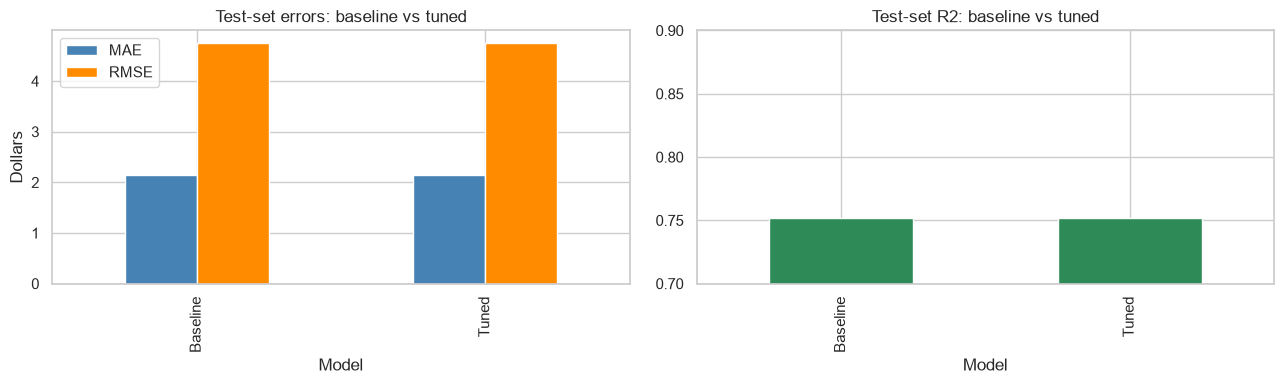

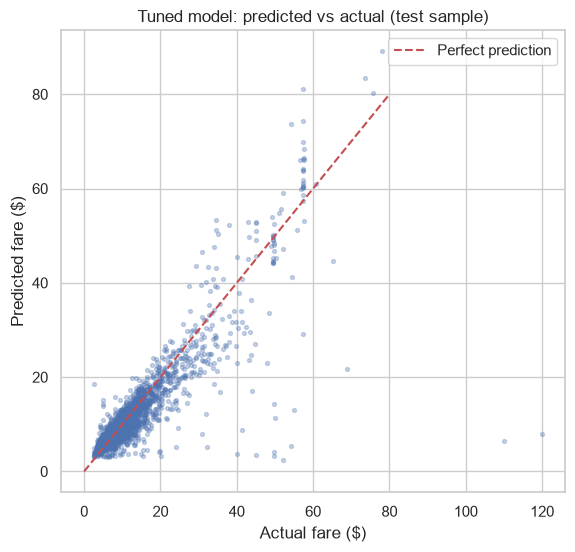

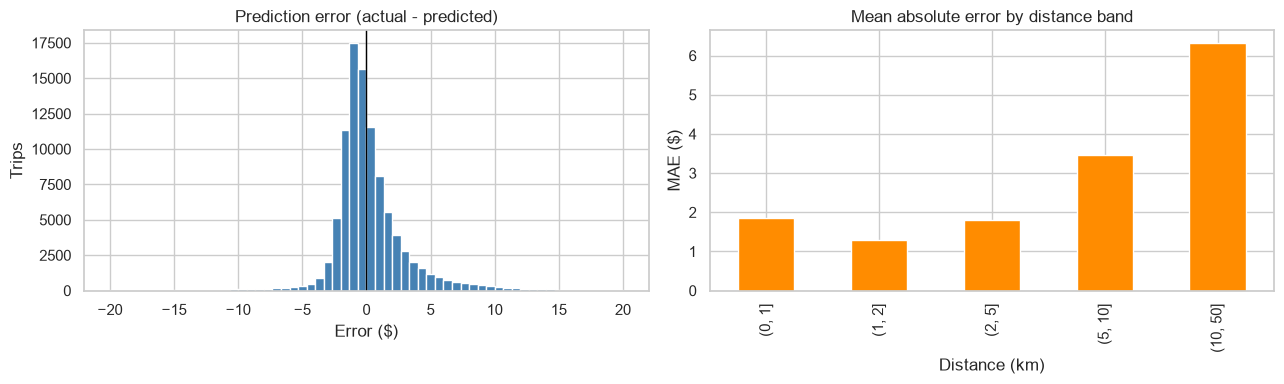

distance
(0, 1]      1.85
(1, 2]      1.28
(2, 5]      1.80
(5, 10]     3.47
(10, 50]    6.33
dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# errors in dollars on the left
results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar", ax=axes[0], color=["steelblue", "darkorange"])
axes[0].set_title("Test-set errors: baseline vs tuned"); axes[0].set_ylabel("Dollars")
# R2 on its own axis, zoomed because the bars are close
results.set_index("Model")["R2"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_ylim(0.7, 0.9)
axes[1].set_title("Test-set R2: baseline vs tuned")
plt.tight_layout(); plt.show()
# 3,000 random test trips, because plotting all of them is unreadable
sample_idx = np.random.RandomState(42).choice(
    len(y_test), size=min(3000, len(y_test)), replace=False)
plt.figure(figsize=(6.5, 6))
# points on the diagonal are perfect predictions
plt.scatter(y_test.iloc[sample_idx], tuned_pred[sample_idx], s=8, alpha=0.3)
plt.plot([0, 80], [0, 80], "r--", lw=1.5, label="Perfect prediction")
plt.xlabel("Actual fare ($)"); plt.ylabel("Predicted fare ($)")
plt.title("Tuned model: predicted vs actual (test sample)"); plt.legend(); plt.show()
# error of every test trip (actual minus predicted)
residuals = y_test.to_numpy() - tuned_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=60, range=(-20, 20), color="steelblue")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Prediction error (actual - predicted)")
axes[0].set_xlabel("Error ($)"); axes[0].set_ylabel("Trips")
# error by trip length, with the index so each error matches its own trip
bands = pd.cut(X_test["distance"], bins=[0, 1, 2, 5, 10, 50])
err_by_band = pd.Series(np.abs(residuals), index=X_test.index).groupby(bands).mean()
err_by_band.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Mean absolute error by distance band")
axes[1].set_xlabel("Distance (km)"); axes[1].set_ylabel("MAE ($)")
plt.tight_layout(); plt.show()
print(err_by_band.round(2))

**Gradient Boosting**
## Step 13: Gradient Boosting
Ridge's score did not move with tuning, so I swapped only the model step for HistGradientBoostingRegressor on the same Pipeline and folds, and tested it with and without SelectKBest because trees do not need aggressive feature selection.

In [27]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import HistGradientBoostingRegressor  # a fast boosting model that needs no extra library
from sklearn.model_selection import cross_validate
# same idea as the linear wrapper: train on log1p(fare) and return dollars
class LogTargetHGB(BaseEstimator, RegressorMixin):
    # step size, number of rounds, tree size and smallest leaf
    def __init__(self, learning_rate=0.1, max_iter=300, max_leaf_nodes=31,
                 min_samples_leaf=20, random_state=42):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.max_leaf_nodes = max_leaf_nodes
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        # remember the fare range for clipping
        self.y_min_, self.y_max_ = float(y.min()), float(y.max())
        self.regressor_ = HistGradientBoostingRegressor(
            learning_rate=self.learning_rate, max_iter=self.max_iter,
            max_leaf_nodes=self.max_leaf_nodes,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state)
        # same log target as Ridge, so the comparison is fair
        self.regressor_.fit(X, np.log1p(y))
        return self
    def predict(self, X):
        # back to dollars, clipped to the training range
        pred = np.expm1(self.regressor_.predict(X))
        return np.clip(pred, self.y_min_, self.y_max_)
# variant 1: same Pipeline with the boosting model, SelectKBest kept
gb_select = clone(model_pipeline).set_params(model=LogTargetHGB())
# variant 2: SelectKBest skipped, because trees can use the features it would drop
gb_all = clone(model_pipeline).set_params(model=LogTargetHGB(), select="passthrough")
rows = {}
# cross-validate both variants on the same folds as the baseline
for name, pipe in {"GB + SelectKBest(14)": gb_select, "GB + all features": gb_all}.items():
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv_strategy, scoring=scoring)
    rows[name] = {
        "MAE ($)": -cv_res["test_mae"].mean(),
        "RMSE ($)": -cv_res["test_rmse"].mean(),
        "R2": cv_res["test_r2"].mean(),
        "R2 std": cv_res["test_r2"].std(),
    }
# add the Ridge baseline (same folds) so all rows can be compared
rows["Ridge baseline (section 10)"] = {
    "MAE ($)": baseline_cv_report["MAE ($)"].mean(),
    "RMSE ($)": baseline_cv_report["RMSE ($)"].mean(),
    "R2": baseline_cv_report["R2"].mean(),
    "R2 std": baseline_cv_report["R2"].std(),
}
gb_cv_table = pd.DataFrame(rows).T
print(gb_cv_table.round(4))

                             MAE ($)  RMSE ($)      R2  R2 std
GB + SelectKBest(14)          1.7070    4.0529  0.8217  0.0238
GB + all features             1.5760    3.9678  0.8290  0.0240
Ridge baseline (section 10)   2.1514    4.7730  0.7530  0.0265


**Gradient Boosting vs Ridge**
## Step 14: Gradient Boosting vs Ridge, Fold by Fold
I compared Gradient Boosting with Ridge on each fold, because a better average alone could be luck, and only then scored it on the test set.

In [30]:
from scipy.stats import ttest_rel  # to test if the gain is more than luck
# pick the better variant using CV only, so the test set stays untouched
gb_only = gb_cv_table.drop(index="Ridge baseline (section 10)")
best_name = gb_only["RMSE ($)"].idxmin()
best_gb_pipe = gb_select if best_name.startswith("GB + Select") else gb_all
print("Chosen by CV RMSE:", best_name)
# run CV again to keep the per-fold scores (same folds as Ridge, so the comparison is paired)
gb_cv = cross_validate(best_gb_pipe, X_train, y_train, cv=cv_strategy, scoring=scoring)
gb_r2 = gb_cv["test_r2"]
ridge_r2 = baseline_cv_report["R2"].to_numpy()
# put both models' R2 per fold side by side
fold_table = pd.DataFrame({
    "Ridge R2": ridge_r2, "GB R2": gb_r2, "GB - Ridge": gb_r2 - ridge_r2})
print(fold_table.round(4))
# winning on every fold is stronger evidence than a better average
print("GB wins in", int((gb_r2 > ridge_r2).sum()), "of 5 folds")
# a paired t-test on the fold differences (only a hint, because the folds share data)
t_stat, p_val = ttest_rel(gb_r2, ridge_r2)
print(f"Paired t-test: t = {t_stat:.2f}, p = {p_val:.4f}")
# fit on the same cleaned training rows Ridge used, then predict the test set
final_gb = clone(best_gb_pipe)
final_gb.fit(X_train_final, y_train_final)
gb_pred = final_gb.predict(X_test)
# add Gradient Boosting to the results table
results_ext = pd.concat(
    [results, pd.DataFrame([{"Model": "Gradient Boosting",
                             **regression_metrics(y_test, gb_pred)}])],
    ignore_index=True)
print("\nFinal held-out test results:")
print(results_ext.round(4).to_string(index=False))
# a saved model must be loaded with the same scikit-learn version
import sklearn
print("\nscikit-learn version:", sklearn.__version__)

Chosen by CV RMSE: GB + all features
   Ridge R2   GB R2  GB - Ridge
0    0.7766  0.8492      0.0725
1    0.7608  0.8341      0.0733
2    0.7469  0.8204      0.0735
3    0.7704  0.8542      0.0838
4    0.7101  0.7873      0.0772
GB wins in 5 of 5 folds
Paired t-test: t = 36.36, p = 0.0000

Final held-out test results:
            Model    MAE   RMSE     R2
         Baseline 2.1537 4.7608 0.7521
            Tuned 2.1537 4.7608 0.7521
Gradient Boosting 1.5575 3.8997 0.8337

scikit-learn version: 1.9.0


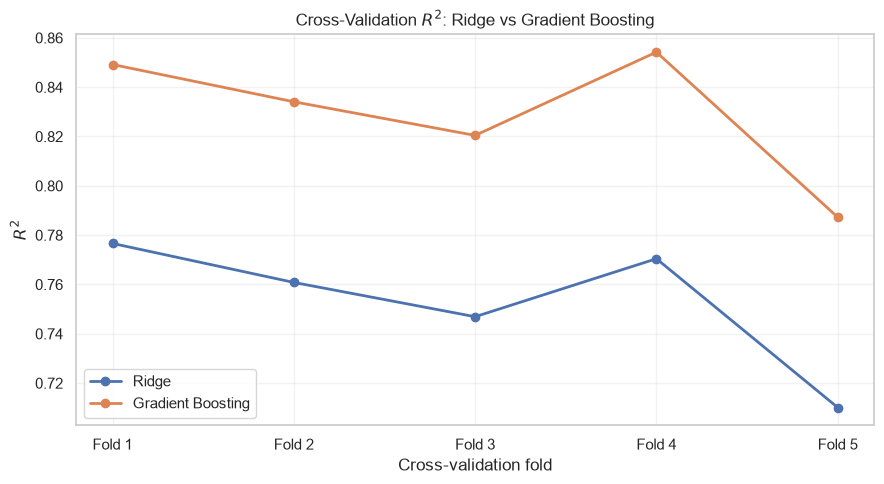

In [31]:
# R2 of both models per fold
fold_plot = fold_table.reset_index().rename(columns={"index": "Fold"})
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(fold_plot))
ax.plot(x, fold_plot["Ridge R2"],
        marker="o", linewidth=2, label="Ridge")
# if this line stays above Ridge on every fold, the gain is consistent
ax.plot(x, fold_plot["GB R2"],
        marker="o", linewidth=2, label="Gradient Boosting")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(len(fold_plot))])
ax.set_ylabel("$R^2$")
ax.set_xlabel("Cross-validation fold")
ax.set_title("Cross-Validation $R^2$: Ridge vs Gradient Boosting")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

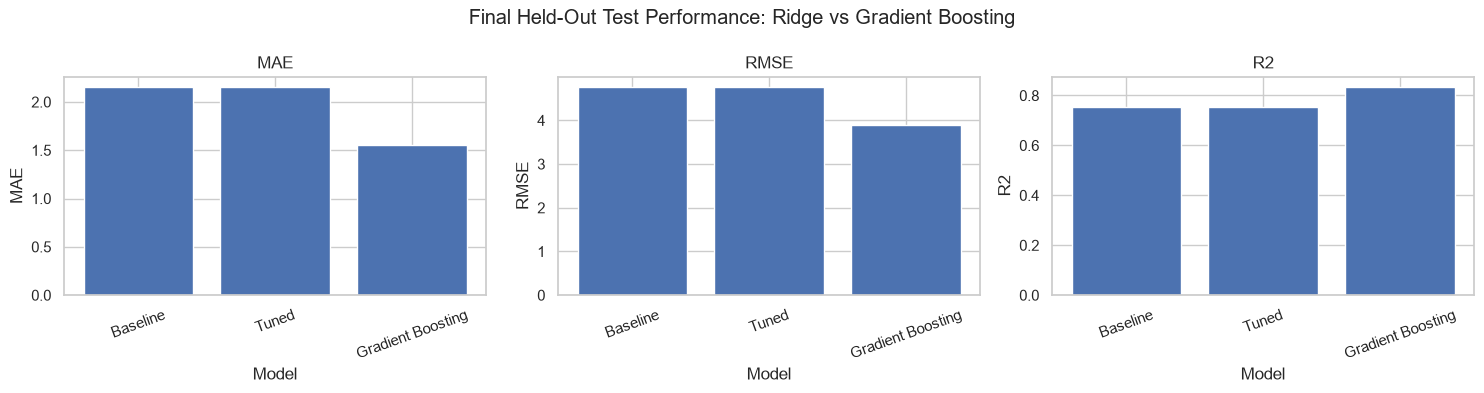

In [32]:
# one chart per metric column, so the code still works if a metric is added
metric_columns = [
    col for col in results_ext.columns
    if col != "Model"
]
fig, axes = plt.subplots(
    1,
    len(metric_columns),
    figsize=(5 * len(metric_columns), 4)
)
# with one metric matplotlib returns a single axis, so wrap it in a list
if len(metric_columns) == 1:
    axes = [axes]
for ax, metric in zip(axes, metric_columns):
    ax.bar(
        results_ext["Model"],
        results_ext[metric]
    )
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel("Model")
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Final Held-Out Test Performance: Ridge vs Gradient Boosting")
plt.tight_layout()
plt.show()

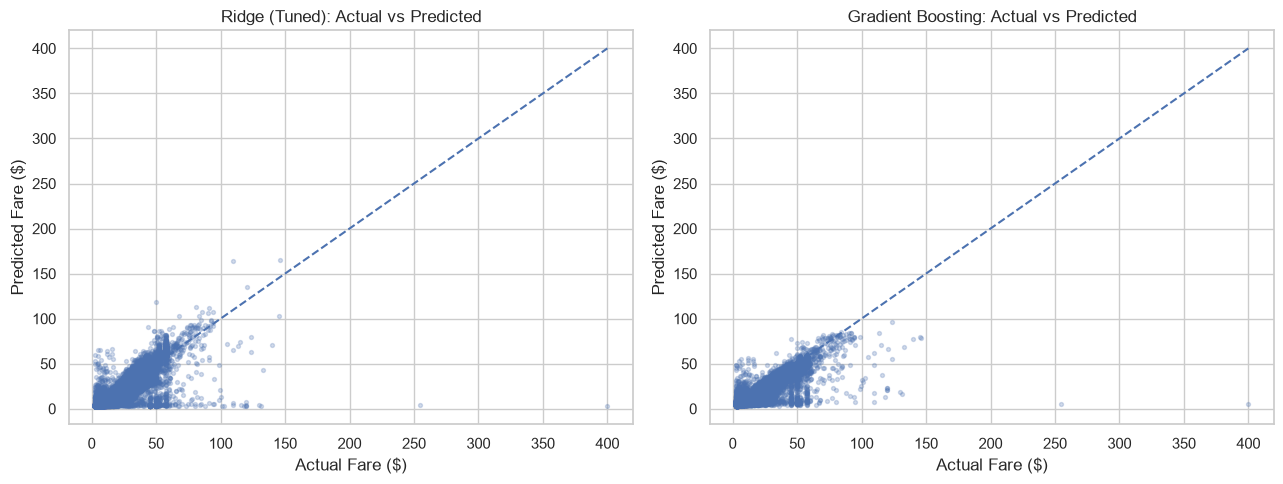

In [33]:
import numpy as np
# the two models to compare on the same test trips
models = [
    ("Ridge (Tuned)", tuned_pred),
    ("Gradient Boosting", gb_pred),
]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, pred) in zip(axes, models):
    # points on the diagonal are perfect predictions
    ax.scatter(y_test, pred, s=8, alpha=0.25)
    limits = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(limits, limits, linestyle="--", linewidth=1.5)
    ax.set_xlabel("Actual Fare ($)")
    ax.set_ylabel("Predicted Fare ($)")
    ax.set_title(f"{name}: Actual vs Predicted")
plt.tight_layout()
plt.show()

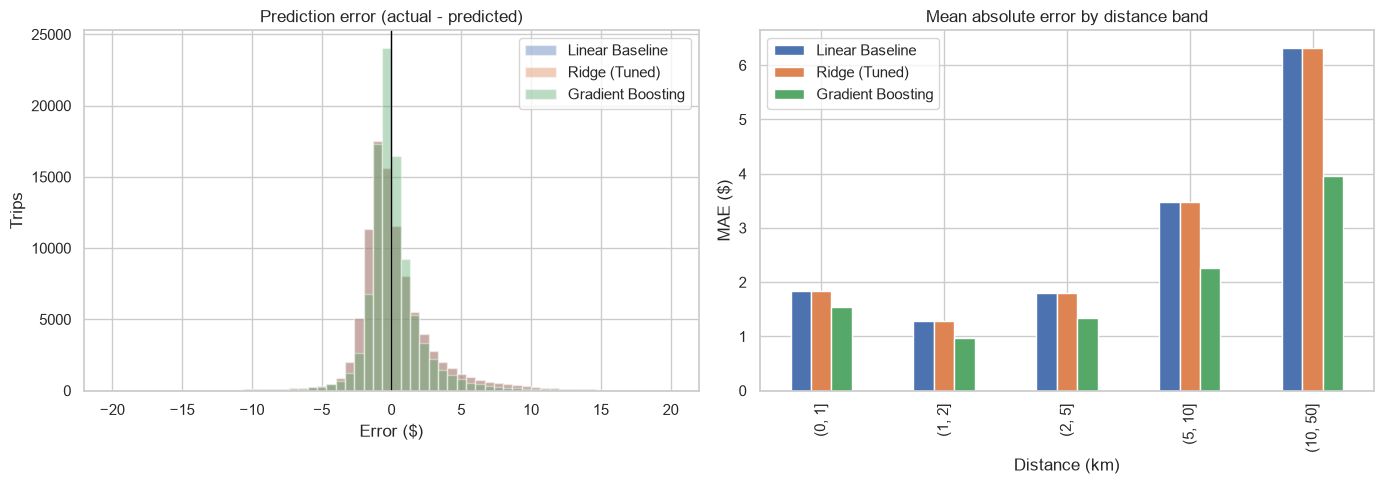

          Linear Baseline  Ridge (Tuned)  Gradient Boosting
distance                                                   
(0, 1]               1.85           1.85               1.54
(1, 2]               1.28           1.28               0.97
(2, 5]               1.80           1.80               1.34
(5, 10]              3.47           3.47               2.25
(10, 50]             6.33           6.33               3.95


In [34]:
import numpy as np
import pandas as pd
# predictions of the three models on the same test trips
preds = {
    "Linear Baseline": baseline_pred,
    "Ridge (Tuned)": tuned_pred,
    "Gradient Boosting": gb_pred,
}
y_arr = y_test.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# a narrower peak around 0 means a more accurate model
for name, p in preds.items():
    axes[0].hist(y_arr - p, bins=60, range=(-20, 20), alpha=0.4, label=name)
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Prediction error (actual - predicted)")
axes[0].set_xlabel("Error ($)")
axes[0].set_ylabel("Trips")
axes[0].legend()
# error by trip length, to see WHERE the models differ
bands = pd.cut(X_test["distance"], bins=[0, 1, 2, 5, 10, 50])
mae_band = pd.DataFrame({
    name: pd.Series(np.abs(y_arr - p), index=X_test.index).groupby(bands, observed=True).mean()
    for name, p in preds.items()
})
mae_band.plot(kind="bar", ax=axes[1])
axes[1].set_title("Mean absolute error by distance band")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("MAE ($)")
plt.tight_layout()
plt.show()
print(mae_band.round(2))

**Model Benchmark**
## Step 15: Model Benchmark and Selection
I compared every candidate on the same Pipeline and the same folds (a fast screen on a 100k sample, then full cross-validation for the best two plus the baseline), because the final model should be chosen by evidence and not by habit.

In [36]:
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor  # the tree models to compare
# a wrapper that trains ANY model on log1p(fare), so all candidates use the same target
class LogTargetEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, estimator=None):
        self.estimator = estimator
    def fit(self, X, y):
        y = np.asarray(y, dtype=float)
        self.y_min_, self.y_max_ = float(y.min()), float(y.max())
        # work on a copy so the original model object stays untouched
        self.estimator_ = clone(self.estimator)
        self.estimator_.fit(X, np.log1p(y))
        return self
    def predict(self, X):
        pred = np.expm1(self.estimator_.predict(X))
        return np.clip(pred, self.y_min_, self.y_max_)

# all candidates in one place, from the simplest to the most complex,
# so adding a model is one entry and the comparison stays fair
registry = {
    "Linear Regression": {
        "estimator": LinearRegression(),
        "select": True,
        "space": {},
    },
    "Ridge": {
        "estimator": Ridge(alpha=best_alpha),
        "select": True,
        "space": {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    },
    "Random Forest": {
        "estimator": RandomForestRegressor(n_estimators=100, min_samples_leaf=10,
                                           max_features=0.5, n_jobs=-1, random_state=42),
        "select": False,
        "space": {"n_estimators": [100, 200], "min_samples_leaf": [5, 10, 20],
                  "max_features": [0.3, 0.5, 0.8]},
    },
    "Extra Trees": {
        "estimator": ExtraTreesRegressor(n_estimators=100, min_samples_leaf=10,
                                         max_features=0.8, n_jobs=-1, random_state=42),
        "select": False,
        "space": {"n_estimators": [100, 200], "min_samples_leaf": [5, 10, 20],
                  "max_features": [0.5, 0.8, 1.0]},
    },
    "Gradient Boosting": {
        "estimator": HistGradientBoostingRegressor(learning_rate=0.1, max_iter=300,
                                                   max_leaf_nodes=31, min_samples_leaf=20,
                                                   random_state=42),
        "select": False,
        "space": {"learning_rate": [0.03, 0.05, 0.1, 0.2], "max_iter": [200, 300, 500],
                  "max_leaf_nodes": [15, 31, 63], "min_samples_leaf": [10, 20, 50]},
    },
}
# LightGBM is optional, so the notebook still runs if it is not installed
try:
    from lightgbm import LGBMRegressor
    registry["LightGBM"] = {
        "estimator": LGBMRegressor(n_estimators=300, learning_rate=0.1, num_leaves=31,
                                   min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1),
        "select": False,
        "space": {"n_estimators": [200, 300, 500], "learning_rate": [0.03, 0.05, 0.1, 0.2],
                  "num_leaves": [15, 31, 63], "min_child_samples": [10, 20, 50]},
    }
except ImportError:
    print("LightGBM is not installed: it is skipped (pip install lightgbm to include it).")

# build the full Pipeline for one candidate (trees skip SelectKBest)
def build_pipeline(name):
    spec = registry[name]
    pipe = clone(model_pipeline).set_params(model=LogTargetEstimator(clone(spec["estimator"])))
    if not spec["select"]:
        pipe.set_params(select="passthrough")
    return pipe

# cross-validate a list of candidates with the same folds and metrics, and return one table
def benchmark(names, X, y):
    rows = {}
    for name in names:
        cv_res = cross_validate(build_pipeline(name), X, y, cv=cv_strategy, scoring=scoring)
        rows[name] = {
            "MAE ($)": -cv_res["test_mae"].mean(),
            "RMSE ($)": -cv_res["test_rmse"].mean(),
            "RMSE std": cv_res["test_rmse"].std(),
            "R2": cv_res["test_r2"].mean(),
            "Fit time (s)": cv_res["fit_time"].mean(),
        }
    return pd.DataFrame(rows).T.sort_values("RMSE ($)")

LightGBM is not installed: it is skipped (pip install lightgbm to include it).


In [37]:
# stage 1: screen every candidate on a sample, because all models on all rows would be slow
n_screen = min(100_000, len(X_train))
X_screen = X_train.sample(n_screen, random_state=42)
y_screen = y_train.loc[X_screen.index]
stage1 = benchmark(list(registry), X_screen, y_screen)
print("Stage 1: screen on", n_screen, "training rows (5 folds)")
print(stage1.round(3))
# stage 2: confirm the best two plus the baseline on all the training data
finalists = list(stage1.index[:2])
if "Linear Regression" not in finalists:
    finalists.append("Linear Regression")
stage2 = benchmark(finalists, X_train, y_train)
print("\nStage 2: full training data (5 folds)")
print(stage2.round(3))
# the winner is the lowest CV RMSE (the test set is not used to choose)
winner_name = stage2.index[0]
print("\nWinner (lowest CV RMSE):", winner_name)
# rank the finalists with the gap to the winner, plus R2 and training time
best_rmse = stage2.iloc[0]["RMSE ($)"]
for rank, (name, row) in enumerate(stage2.iterrows(), start=1):
    gap = (row["RMSE ($)"] / best_rmse - 1) * 100
    print(f"{rank}. {name}: RMSE ${row['RMSE ($)']:.2f} ({gap:+.1f}% vs best), "
          f"R2 {row['R2']:.3f}, fit {row['Fit time (s)']:.0f}s per fold")
# the simplest model within one std of the winner, because a simple model that is as good can be the better choice
limit = best_rmse + stage2.iloc[0]["RMSE std"]
within = [n for n in registry if n in stage2.index and stage2.loc[n, "RMSE ($)"] <= limit]
print("Simplest model within one std of the best:", within[0])
# keep the evidence in a file
pd.concat({"stage1_sample": stage1, "stage2_full": stage2}).to_csv("model_benchmark.csv")

Stage 1: screen on 100000 training rows (5 folds)
                   MAE ($)  RMSE ($)  RMSE std     R2  Fit time (s)
Gradient Boosting    1.617     3.925     0.449  0.830         2.854
Random Forest        1.688     4.045     0.427  0.820        19.377
Extra Trees          1.765     4.113     0.420  0.814        11.357
Ridge                2.147     4.645     0.380  0.763         9.936
Linear Regression    2.147     4.645     0.380  0.763        10.330

Stage 2: full training data (5 folds)
                   MAE ($)  RMSE ($)  RMSE std     R2  Fit time (s)
Gradient Boosting    1.576     3.968     0.353  0.829         7.484
Random Forest        1.609     4.037     0.342  0.823        70.960
Linear Regression    2.151     4.773     0.317  0.753         8.739

Winner (lowest CV RMSE): Gradient Boosting
1. Gradient Boosting: RMSE $3.97 (+0.0% vs best), R2 0.829, fit 7s per fold
2. Random Forest: RMSE $4.04 (+1.7% vs best), R2 0.823, fit 71s per fold
3. Linear Regression: RMSE $4.77 (+20.

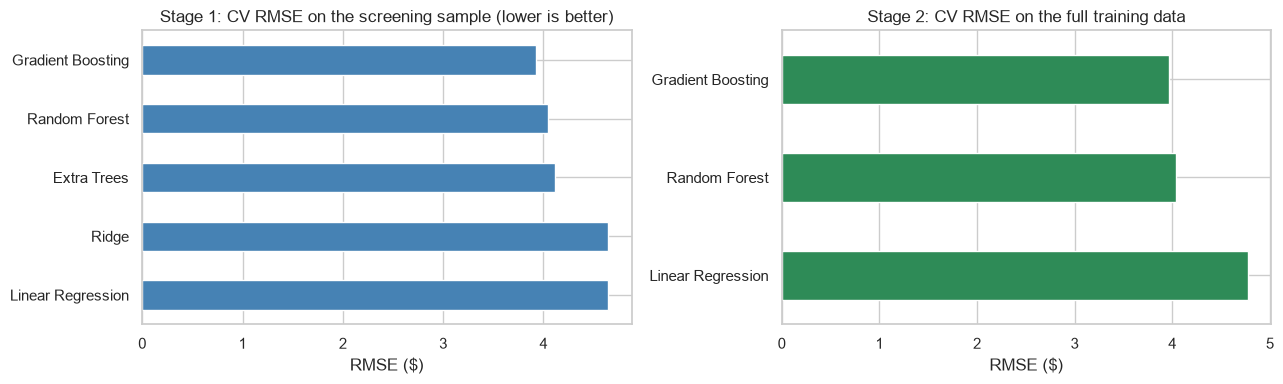

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# stage 1: the shortest bar is the best model on the sample
stage1["RMSE ($)"].sort_values(ascending=False).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Stage 1: CV RMSE on the screening sample (lower is better)")
axes[0].set_xlabel("RMSE ($)")
# stage 2: the same chart on the full training data
stage2["RMSE ($)"].sort_values(ascending=False).plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Stage 2: CV RMSE on the full training data")
axes[1].set_xlabel("RMSE ($)")
plt.tight_layout(); plt.show()

**Tuning the Winner**
## Step 16: Hyperparameter Tuning
I tuned with RandomizedSearchCV (up to 10 random combinations, same folds, search space registered for that model), because tuning every model would be slow and most of them already lost.

In [39]:
from sklearn.model_selection import RandomizedSearchCV  # tries random combinations instead of all of them
# the settings registered for the winner
space = registry[winner_name]["space"]
# Linear Regression has nothing to tune
if space:
    # rename the settings so the Pipeline can reach them (model -> estimator -> setting)
    param_dist = {f"model__estimator__{k}": v for k, v in space.items()}
    # how many combinations exist, to know how much 10 tries cover
    n_combos = int(np.prod([len(v) for v in space.values()]))
    # random search on the cleaned training rows, with the same folds and metrics as before
    winner_search = RandomizedSearchCV(
        estimator=build_pipeline(winner_name),
        param_distributions=param_dist,
        n_iter=min(10, n_combos),
        cv=cv_strategy,
        scoring=scoring,
        refit="rmse",
        random_state=42,
        n_jobs=1,
    )
    winner_search.fit(X_train_final, y_train_final)
    # keep the best Pipeline found
    tuned_winner = winner_search.best_estimator_
    print("Search space size:", n_combos, "combinations | tried:", min(10, n_combos))
    print("Best params:", winner_search.best_params_)
    print("Best CV RMSE ($):", -winner_search.best_score_)
else:
    # nothing to tune, so just fit the model as it is
    tuned_winner = build_pipeline(winner_name).fit(X_train_final, y_train_final)
    print(winner_name, "has no hyperparameters to tune: fitted as it is.")
# first look at the tuned winner on the test set
tuned_winner_pred = tuned_winner.predict(X_test)
print(regression_metrics(y_test, tuned_winner_pred))

Search space size: 108 combinations | tried: 10
Best params: {'model__estimator__min_samples_leaf': 50, 'model__estimator__max_leaf_nodes': 31, 'model__estimator__max_iter': 500, 'model__estimator__learning_rate': 0.1}
Best CV RMSE ($): 3.4211205667139835
{'MAE': 1.5389610568980148, 'RMSE': np.float64(3.8650033457716857), 'R2': 0.8366336742409004}


**Final Pipeline**
## Step 17: Final Pipeline and Results Table
The final model is the tuned winner of the benchmark, saved as a single joblib file and compared with the baseline on the held-out test set.

In [41]:
import os  # to read the file size
import time  # to measure the prediction speed
# the final model is the tuned winner (the assert checks it is really a Pipeline)
final_pipeline = tuned_winner
assert isinstance(final_pipeline, Pipeline), "Final object must be a Pipeline"
# save preprocessing + model together in ONE file
joblib.dump(final_pipeline, "final_pipeline.joblib")
# load it back, to prove the saved file itself works
loaded_final = joblib.load("final_pipeline.joblib")
assert isinstance(loaded_final, Pipeline), "Loaded object must be a Pipeline"
# predict the test set with the loaded file, without refitting
final_pred = loaded_final.predict(X_test)
# the winner with default settings, to see what tuning added
winner_default = build_pipeline(winner_name).fit(X_train_final, y_train_final)
winner_default_pred = winner_default.predict(X_test)
# the final results table: baseline vs tuned (plus the steps in between)
results_final = pd.DataFrame([
    {"Model": "Baseline (Linear Regression)", **regression_metrics(y_test, baseline_pred)},
    {"Model": "Tuned Ridge", **regression_metrics(y_test, tuned_pred)},
    {"Model": f"{winner_name} (default settings)", **regression_metrics(y_test, winner_default_pred)},
    {"Model": f"{winner_name} (tuned, final)", **regression_metrics(y_test, final_pred)},
])
print("Held-out test results:")
print(results_final.round(4).to_string(index=False))
# a slow model is hard to deploy, so measure the prediction time
start = time.perf_counter()
loaded_final.predict(X_test.iloc[:10000])
elapsed = time.perf_counter() - start
print(f"\nPredicting 10,000 trips takes {elapsed:.2f} s")
# a huge file is hard to share, so check the size
print(f"File size: {os.path.getsize('final_pipeline.joblib') / 1e6:.1f} MB")
# the file must be loaded later with the same scikit-learn version
import sklearn
print("Pipeline steps:", [name for name, _ in loaded_final.steps])
print("Saved file: final_pipeline.joblib | scikit-learn", sklearn.__version__)

Held-out test results:
                               Model    MAE   RMSE     R2
        Baseline (Linear Regression) 2.1537 4.7608 0.7521
                         Tuned Ridge 2.1537 4.7608 0.7521
Gradient Boosting (default settings) 1.5575 3.8997 0.8337
    Gradient Boosting (tuned, final) 1.5390 3.8650 0.8366

Predicting 10,000 trips takes 0.11 s
File size: 1.4 MB
Pipeline steps: ['log_distance', 'eda_features', 'preprocess', 'select', 'model']
Saved file: final_pipeline.joblib | scikit-learn 1.9.0


**Extra Analysis**
## Step 18: Extra Analysis
These checks explain the final model: which inputs matter and how accurate it is in plain dollars.

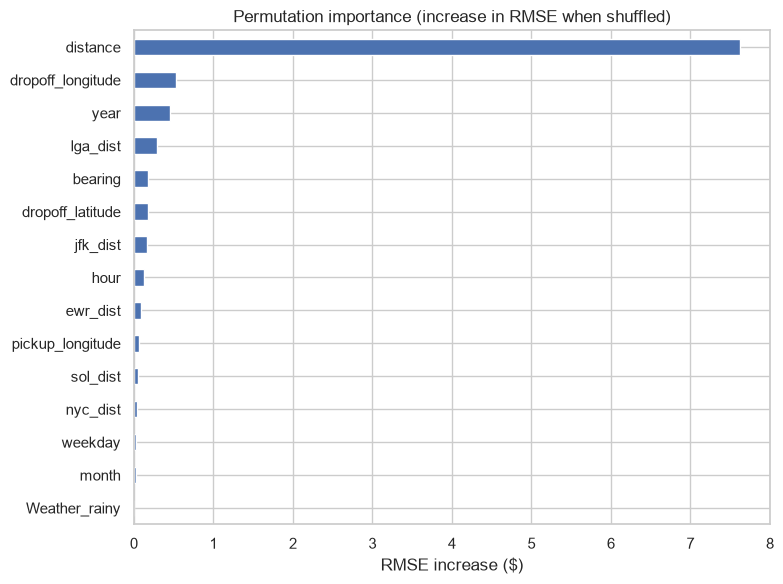

In [42]:
from sklearn.inspection import permutation_importance  # shuffle a column and see how much the error grows
import pandas as pd
import matplotlib.pyplot as plt
# 2,000 test rows are enough and keep it fast
sample = X_test.sample(2000, random_state=42)
y_sample = y_test.loc[sample.index]
# if shuffling a column barely changes the RMSE, the model does not use it
perm = permutation_importance(
    final_pipeline, sample, y_sample,
    scoring="neg_root_mean_squared_error",
    n_repeats=3, random_state=42, n_jobs=-1,
)
imp = pd.Series(perm.importances_mean, index=sample.columns).sort_values()
# show only the top 15, because a long list of near-zero bars adds noise
imp.tail(15).plot(kind="barh", figsize=(8, 6))
plt.title("Permutation importance (increase in RMSE when shuffled)")
plt.xlabel("RMSE increase ($)")
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import median_absolute_error  # a typical error that outliers cannot pull up
# the baseline, the tuned Ridge and the final model on the same test trips
preds = {
    "Linear Baseline": baseline_pred,
    "Ridge (Tuned)": tuned_pred,
    "Final model": final_pred,
}
y_arr = y_test.to_numpy()
# easy numbers to explain: the share of trips predicted within $2, $3 and $5
rows = []
for name, p in preds.items():
    err = np.abs(y_arr - p)
    rows.append({
        "Model": name,
        "Median AE ($)": median_absolute_error(y_arr, p),
        "Within $2 (%)": (err <= 2).mean() * 100,
        "Within $3 (%)": (err <= 3).mean() * 100,
        "Within $5 (%)": (err <= 5).mean() * 100,
    })
print(pd.DataFrame(rows).round(2).to_string(index=False))
# a bootstrap shows if the gap between models is bigger than the noise of this test set
rng = np.random.RandomState(42)
n = len(y_arr)
for name, p in preds.items():
    boot = []
    # resample the test trips 300 times and compute the RMSE each time
    for _ in range(300):
        idx = rng.randint(0, n, n)
        boot.append(np.sqrt(np.mean((y_arr[idx] - p[idx]) ** 2)))
    # the middle 95% of the 300 values; if two intervals do not overlap, the models really differ
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"{name}: RMSE 95% CI = [{lo:.3f}, {hi:.3f}]")

          Model  Median AE ($)  Within $2 (%)  Within $3 (%)  Within $5 (%)
Linear Baseline           1.22          71.43          83.57          91.54
  Ridge (Tuned)           1.22          71.43          83.57          91.54
    Final model           0.82          81.45          89.43          95.33
Linear Baseline: RMSE 95% CI = [4.441, 5.198]
Ridge (Tuned): RMSE 95% CI = [4.428, 5.197]
Final model: RMSE 95% CI = [3.514, 4.299]


**Short Results Table**
## Step 17b: Baseline vs Tuned Model
The task asks for a short table, so we keep only the baseline and the final tuned model, scored on the held-out test set.

In [45]:
# build the short table: only the baseline and the final tuned model
results_short = pd.DataFrame([
    {"Model": "Baseline (Linear Regression)", **regression_metrics(y_test, baseline_pred)},
    {"Model": f"Tuned {winner_name} (final)", **regression_metrics(y_test, final_pred)},
])
# show it with 4 decimals
print(results_short.round(4).to_string(index=False))
# how much the errors dropped, in percent, to quote in the report
mae_drop = (1 - results_short.loc[1, "MAE"] / results_short.loc[0, "MAE"]) * 100
rmse_drop = (1 - results_short.loc[1, "RMSE"] / results_short.loc[0, "RMSE"]) * 100
print(f"\nMAE dropped by {mae_drop:.1f}% and RMSE dropped by {rmse_drop:.1f}%")

                          Model    MAE   RMSE     R2
   Baseline (Linear Regression) 2.1537 4.7608 0.7521
Tuned Gradient Boosting (final) 1.5390 3.8650 0.8366

MAE dropped by 28.5% and RMSE dropped by 18.8%


## What I Would Try Next
First, I would move the encoding into the Pipeline so the saved file accepts a raw row. Then I would try Optuna for a smarter search than random sampling, stack Ridge with the best tree model, use SHAP to see where the model still fails (fixed airport fares and trips over 10 km), try target encoding if I add a high-cardinality column such as a pickup zone, and re-check the results with a time-based split because of the September 2012 price change.